In [1]:
import celltypist
from celltypist import models
import scanpy as sc

c:\Users\user\OneDrive\Desktop\GitHub\BioWorkbench\env\Lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
adata_2000 = sc.read('celltypist_demo_folder/demo_2000_cells.h5ad', backup_url = 'https://celltypist.cog.sanger.ac.uk/Notebook_demo_data/demo_2000_cells.h5ad')

c:\Users\user\OneDrive\Desktop\GitHub\BioWorkbench\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 34.1M/34.1M [00:03<00:00, 11.9MB/s]


In [3]:
models.download_models(force_update = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in C:\Users\user\.celltypist\data\models
💾 Downloading model [1/61]: Immune_All_Low.pkl
💾 Downloading model [2/61]: Immune_All_High.pkl
💾 Downloading model [3/61]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/61]: Adult_Human_MTG.pkl
💾 Downloading model [6/61]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/61]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/61]: Adult_Human_Skin.pkl
💾 Downloading model [9/61]: Adult_Human_Vascular.pkl
💾 Downloading model [10/61]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/61]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/61]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/61]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/61]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/61]: Adult_cHSPCs_Ultima.pkl
💾 D

In [4]:
models.models_description()

👉 Detailed model information can be found at `https://www.celltypist.org/models`


,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...
...,...,...
56,Nuclei_Lung_Airway.pkl,cell populations from snRNA-seq of five locati...
57,PaediatricAdult_COVID19_Airway.pkl,cell types in the airway of paediatric and adu...
58,PaediatricAdult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types of pae...
59,Pan_Fetal_Human.pkl,stromal and immune populations from the human ...


In [5]:
model = models.Model.load(model = 'Immune_All_Low.pkl')

In [6]:
predictions = celltypist.annotate(adata_2000, model = 'Immune_All_Low.pkl', majority_voting = True)

🔬 Input data has 2000 cells and 18950 genes
🔗 Matching reference genes in the model
🧬 5645 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


In [7]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
cell1,Plasma cells,0,Plasma cells
cell2,Plasma cells,1,Plasma cells
cell3,Plasma cells,2,gamma-delta T cells
cell4,Plasma cells,3,Plasma cells
cell5,Plasma cells,3,Plasma cells
...,...,...,...
cell1996,HSC/MPP,43,Neutrophil-myeloid progenitor
cell1997,Neutrophil-myeloid progenitor,42,Neutrophil-myeloid progenitor
cell1998,Neutrophil-myeloid progenitor,40,Neutrophil-myeloid progenitor
cell1999,Neutrophil-myeloid progenitor,42,Neutrophil-myeloid progenitor


In [8]:
adata = predictions.to_adata()

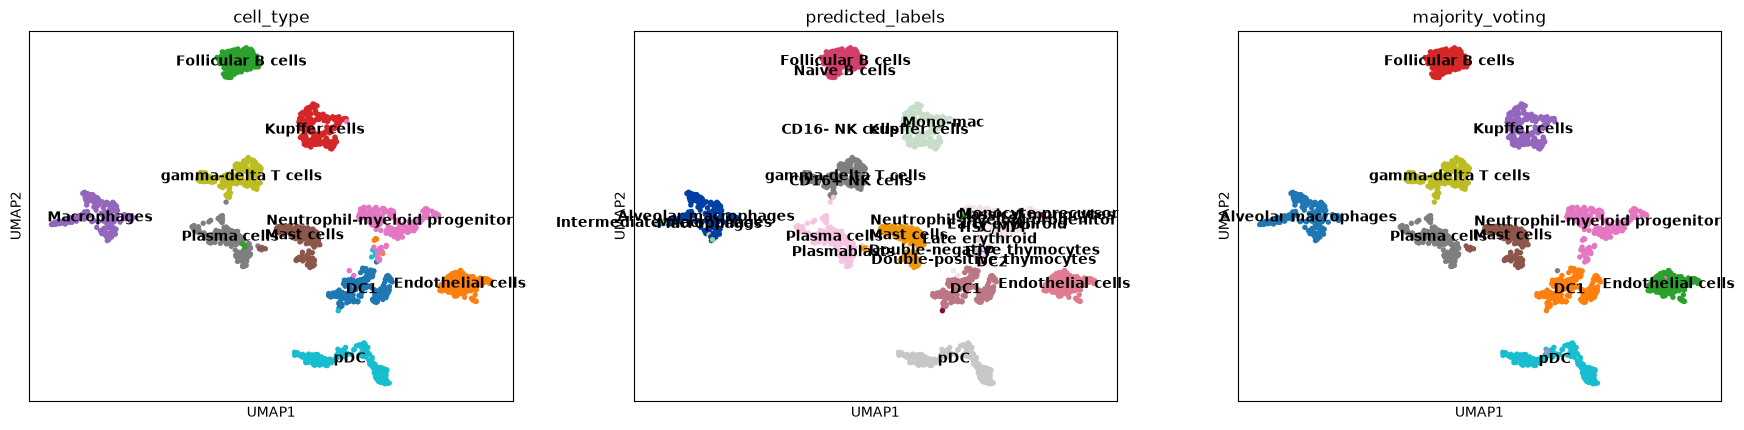

In [9]:
sc.tl.umap(adata)
sc.pl.umap(adata, color = ['cell_type', 'predicted_labels', 'majority_voting'], legend_loc = 'on data')

In [11]:
adata_2000

AnnData object with n_obs × n_vars = 2000 × 18950
    obs: 'cell_type', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
    uns: 'neighbors', 'over_clustering', 'umap', 'cell_type_colors', 'predicted_labels_colors', 'majority_voting_colors'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'
    layers: None (.X)